# Homework 2


In [16]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

## Problem 1


In [17]:
def myfunc(x, y):
    z = x + y
    print("%d" % z)


def myfunc2(x, y):
    z = x + y
    print("%d" % z)
    return z


def myfunc3(x, y=5):
    z = x + y
    print("%d" % z)
    return z


result1 = myfunc(1, 2)
result2 = myfunc2(1, 2)
result3 = myfunc3(5, 3)

print("1) " + str(result1))  # Outputs None due to no return statement in the function
print("2) " + str(result2))
print("3) " + str(result3))

3
3
8
1) None
2) 3
3) 8


## Problem 2

    Model 1 - C
    Model 2 - A
    Model 3 - B


## Problem 3


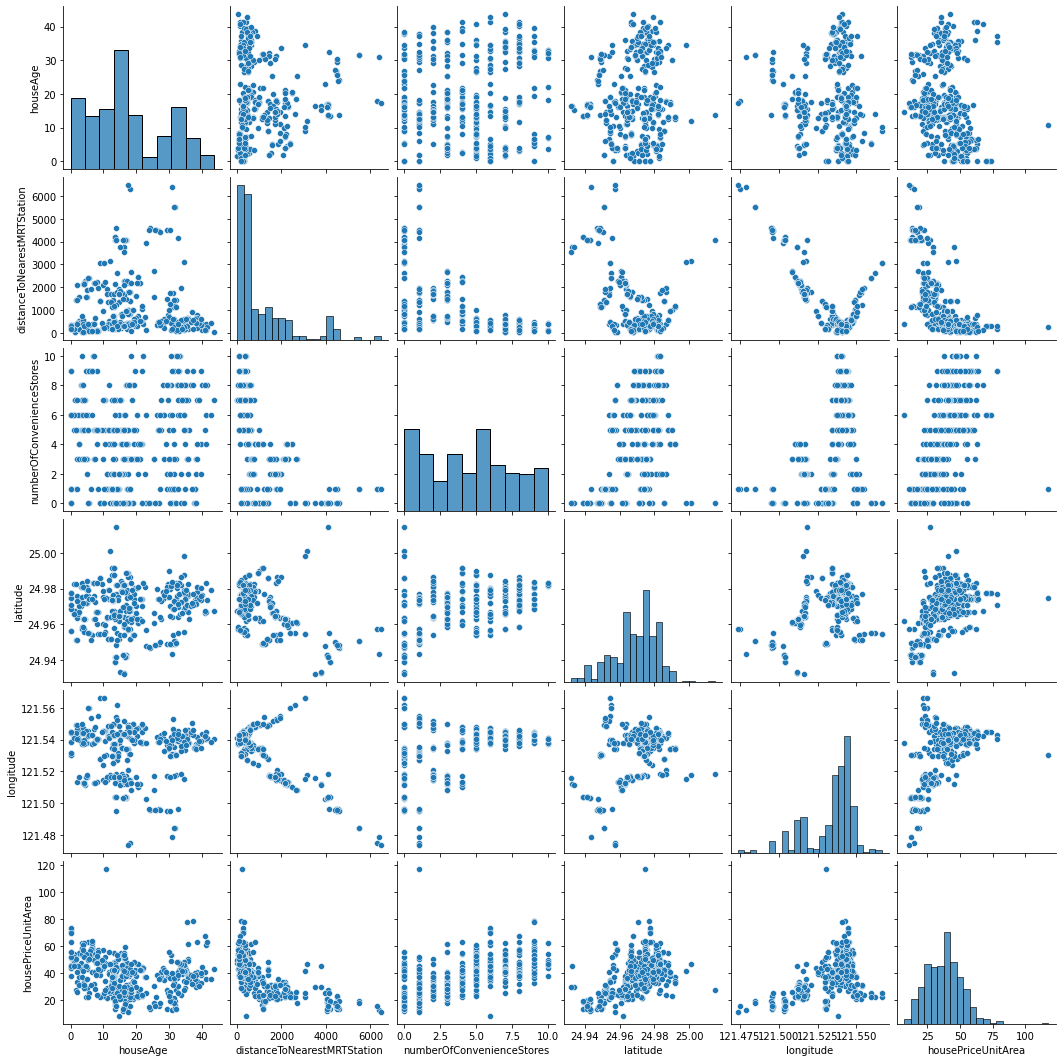

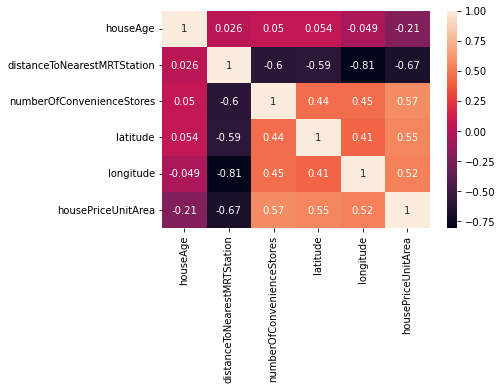

Coefficients: 
[-2.68916833e-01 -4.25908898e-03  1.16302048e+00  2.37767191e+02
 -7.80545273e+00]
Intercept: 
-4945.5951137428565


In [18]:
# Read data from csv
data = pd.read_csv("Real_estate_valuation_dataset_HW2.csv")

x = data[
    [
        "houseAge",
        "distanceToNearestMRTStation",
        "numberOfConvenienceStores",
        "latitude",
        "longitude",
    ]
]
y = data["housePriceUnitArea"]

# Visualize pairplot and correlation heatmap
sns.pairplot(data)
plt.show()

correlation = data.corr()
sns.heatmap(correlation, annot=True)
plt.show()

# Fit linear regression with intercept and report coefficients
model = LinearRegression(fit_intercept=True)
model.fit(x, y)
print("Coefficients: ")
print(model.coef_)
print("Intercept: ")
print(model.intercept_)

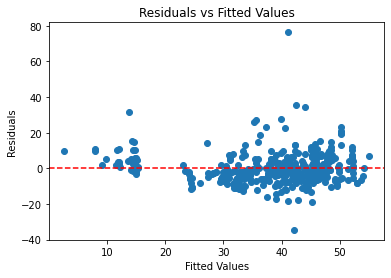

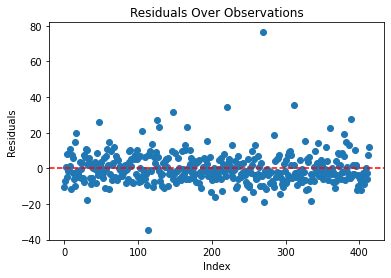

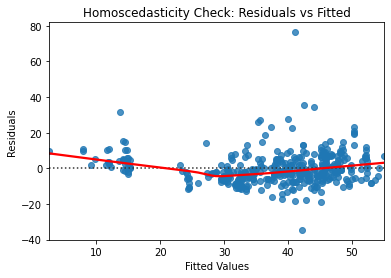

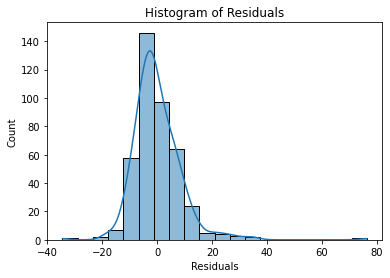

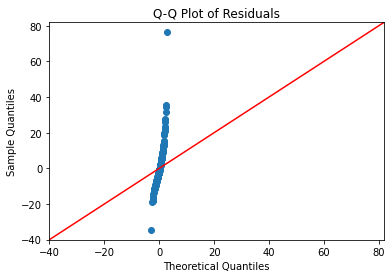

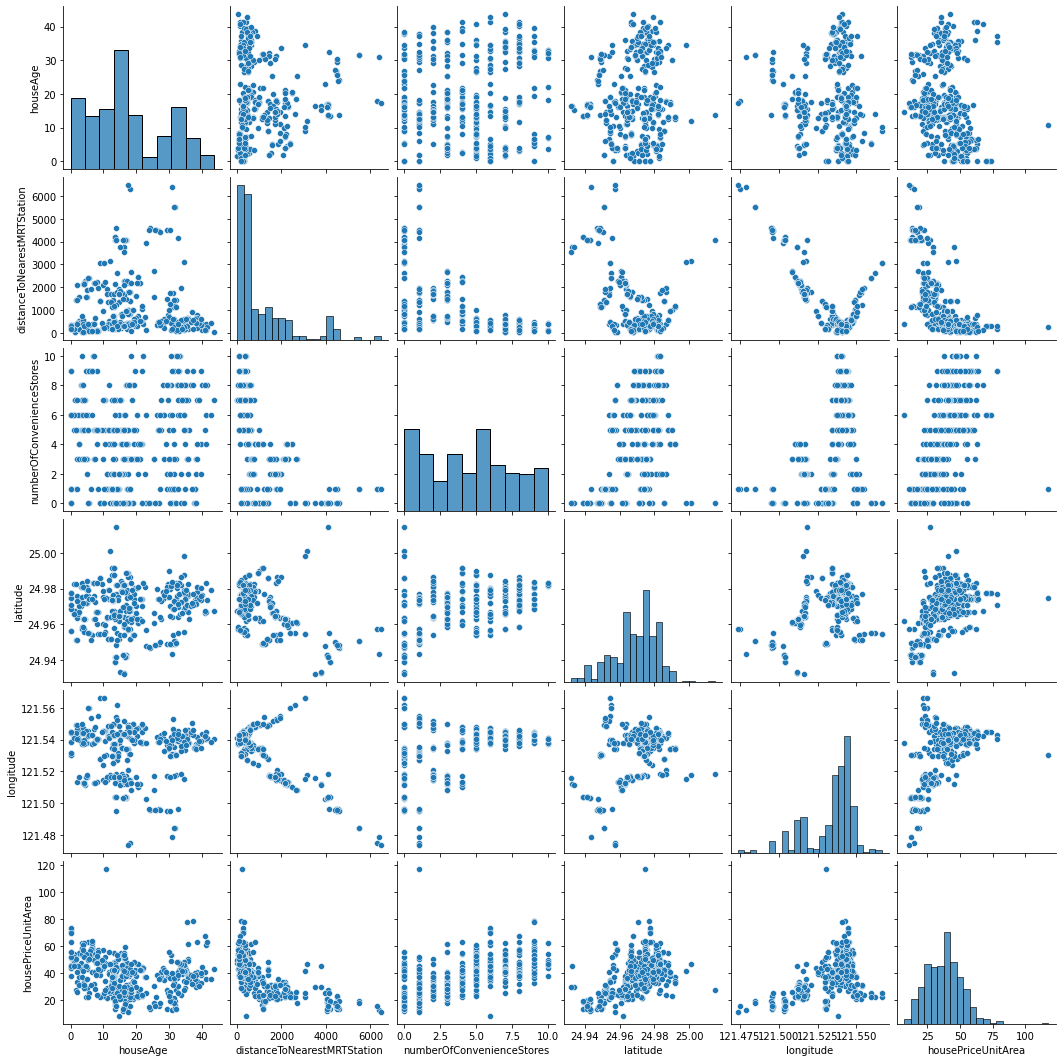

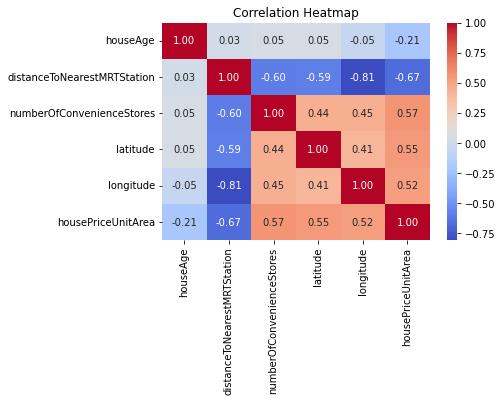

In [19]:
# Add a constant term for the regression model
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Get residuals and fitted values
data["fitted_values"] = model.fittedvalues
data["residuals"] = model.resid

# 1. Linearity: Residuals vs. Fitted Values
plt.scatter(data["fitted_values"], data["residuals"])
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# 2. Independence: Residuals over index
plt.plot(data.index, data["residuals"], marker="o", linestyle="")
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Residuals")
plt.title("Residuals Over Observations")
plt.show()

# 3. Homoscedasticity: Residuals vs. Fitted Values with Lowess line
sns.residplot(
    x=data["fitted_values"], y=data["residuals"], lowess=True, line_kws={"color": "red"}
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check: Residuals vs Fitted")
plt.show()

# 4. Normality Check: Histogram
sns.histplot(data["residuals"], kde=True, bins=20)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.show()

# 4. Normality Check: Q-Q Plot
sm.qqplot(data["residuals"], line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

# 5. Multicollinearity: Pairplot
sns.pairplot(
    data[
        [
            "houseAge",
            "distanceToNearestMRTStation",
            "numberOfConvenienceStores",
            "latitude",
            "longitude",
            "housePriceUnitArea",
        ]
    ]
)
plt.show()

# 5. Multicollinearity: Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    data[
        [
            "houseAge",
            "distanceToNearestMRTStation",
            "numberOfConvenienceStores",
            "latitude",
            "longitude",
            "housePriceUnitArea",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
# R^2 values for each model
print("R^2 values for each model:")

# Model 1: houseAge
houseAge_feature = sm.add_constant(data["houseAge"])
model1 = sm.OLS(y, houseAge_feature).fit()
print(f"Model1: {model1.rsquared}")

# Model 2: houseAge, distanceToNearestMRTStation
dist = sm.add_constant(data[["houseAge", "distanceToNearestMRTStation"]])
model2 = sm.OLS(y, dist).fit()
print(f"Model2: {model2.rsquared}")

# Model 3: houseAge, distanceToNearestMRTStation, numberOfConvenienceStores
conv = sm.add_constant(
    data[["houseAge", "distanceToNearestMRTStation", "numberOfConvenienceStores"]]
)
model3 = sm.OLS(y, conv).fit()
print(f"Model3: {model3.rsquared}")

# Model 4: houseAge, distanceToNearestMRTStation, numberOfConvenienceStores, latitude
lat = sm.add_constant(
    data[
        [
            "houseAge",
            "distanceToNearestMRTStation",
            "numberOfConvenienceStores",
            "latitude",
        ]
    ]
)
model4 = sm.OLS(y, lat).fit()
print(f"Model4: {model4.rsquared}")

# Model 5: houseAge, distanceToNearestMRTStation, numberOfConvenienceStores, latitude, longitude
longitude = sm.add_constant(
    data[
        [
            "houseAge",
            "distanceToNearestMRTStation",
            "numberOfConvenienceStores",
            "latitude",
            "longitude",
        ]
    ]
)
model5 = sm.OLS(y, longitude).fit()
print(f"Model5: {model5.rsquared}")

R^2 values for each model:
Model1: 0.04433848097791193
Model2: 0.49114669575911474
Model3: 0.5410632980005723
Model4: 0.5711351969713656
Model5: 0.5711617064827446


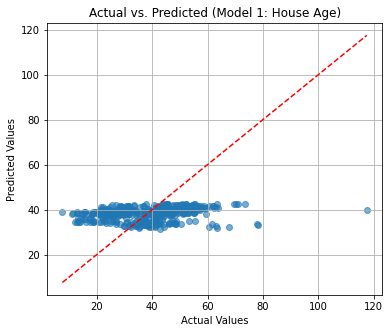

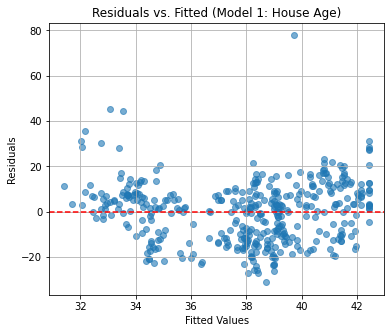

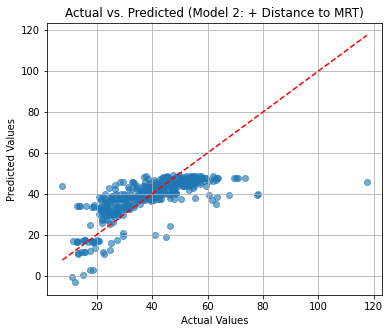

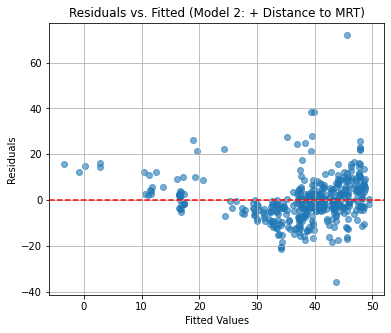

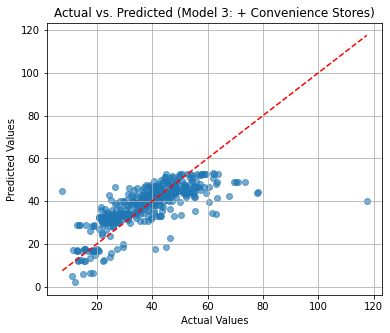

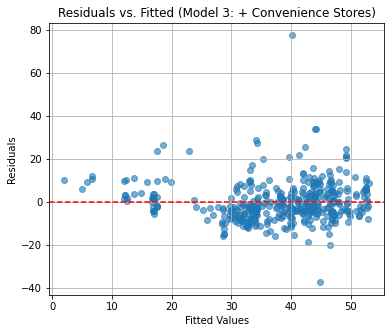

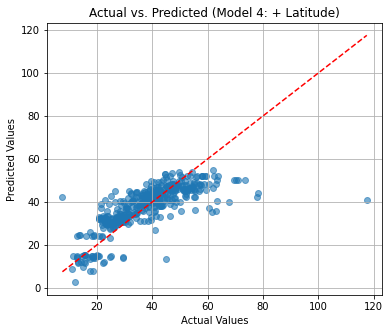

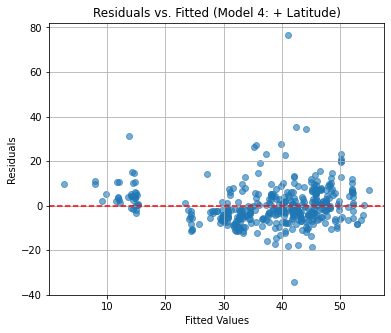

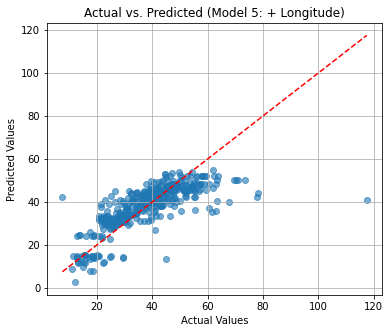

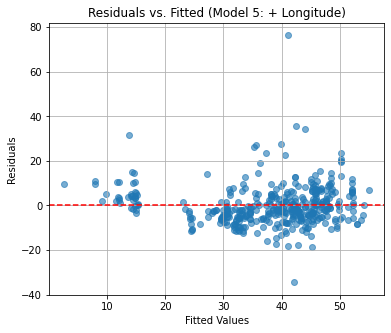

In [ ]:
# Define models with incrementally added features
models = []
features_list = [
    ["houseAge"],  # Model 1
    ["houseAge", "distanceToNearestMRTStation"],  # Model 2
    ["houseAge", "distanceToNearestMRTStation", "numberOfConvenienceStores"],  # Model 3
    [
        "houseAge",
        "distanceToNearestMRTStation",
        "numberOfConvenienceStores",
        "latitude",
    ],  # Model 4
    [
        "houseAge",
        "distanceToNearestMRTStation",
        "numberOfConvenienceStores",
        "latitude",
        "longitude",
    ],  # Model 5
]

# Fit models and store them
for features in features_list:
    X = sm.add_constant(data[features])
    model = sm.OLS(y, X).fit()
    models.append((features, model))

# Titles for plots
titles = [
    "Model 1: House Age",
    "Model 2: + Distance to MRT",
    "Model 3: + Convenience Stores",
    "Model 4: + Latitude",
    "Model 5: + Longitude",
]

# Generate plots for each model
for i, (features, model) in enumerate(models):
    # Get predictions
    data[f"fitted_values_{i+1}"] = model.fittedvalues
    residuals = y - data[f"fitted_values_{i+1}"]

    # Actual vs. Predicted
    plt.figure(figsize=(6, 5))
    plt.scatter(y, data[f"fitted_values_{i+1}"], alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")  # 45-degree reference line
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs. Predicted ({titles[i]})")
    plt.grid(True)
    plt.show()

    # Residuals vs. Fitted
    plt.figure(figsize=(6, 5))
    plt.scatter(data[f"fitted_values_{i+1}"], residuals, alpha=0.6)
    plt.axhline(y=0, color="r", linestyle="--")
    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs. Fitted ({titles[i]})")
    plt.grid(True)
    plt.show()